In [1]:
!pip install opencv-python-headless


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread('D:\IPCV\LAB-EXP-6\images\1.jpeg',0)

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\ACER\AppData\Local\Temp\ipykernel_2248\1929619067.py:1: SyntaxWarning: invalid escape sequence '\I'
  img = cv2.imread('D:\IPCV\LAB-EXP-6\images\1.jpeg',0)


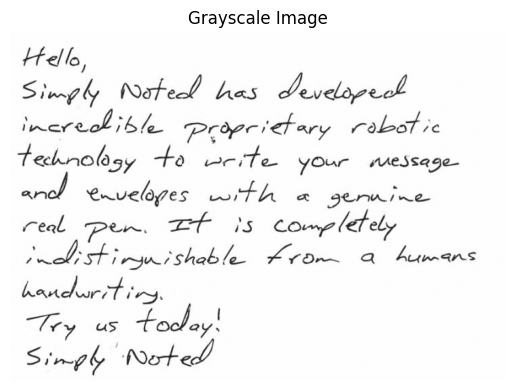

In [6]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r'D:\IPCV\LAB-EXP-6\images\1.jpeg', 0)

plt.imshow(img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')   # hide axes
plt.show()

In [7]:
kernel = np.ones((5,5),np.float32)/25

In [8]:
blurred = cv2.filter2D(img,-1,kernel)

In [9]:
noise = 20*np.random.randn(img.shape[0],img.shape[1])

In [10]:
noise = noise.reshape(1,-1)

In [13]:
noise = np.random.normal(0, 0.1, blurred.shape)
noisy = blurred + noise

In [15]:
noisy = np.clip(noisy,0,255).astype(np.uint8)

In [16]:
f = np.fft.fft2(noisy)

In [17]:
f_shift = np.fft.fftshift(f)

In [18]:
h = np.fft.fft2(kernel,s=img.shape)

In [19]:
print(h)

[[0.99999994-6.9388939e-17j 0.9997778 -1.7212082e-02j
  0.99911124-3.4411412e-02j ... 0.9980011 +5.1585253e-02j
  0.99911124+3.4411412e-02j 0.99977773+1.7212082e-02j]
 [0.9995517 -2.4442103e-02j 0.99890894-4.1641038e-02j
  0.99782234-5.8816370e-02j ... 0.99881464+2.7168887e-02j
  0.9995045 +9.9756075e-03j 0.9997503 -7.2323056e-03j]
 [0.99820787-4.8847690e-02j 0.9971453 -6.6018075e-02j
  0.9956398 -8.3154023e-02j ... 0.9987324 +2.7427580e-03j
  0.9990017 -1.4454534e-02j 0.99882686-3.1655602e-02j]
 ...
 [0.9959707 +7.3180318e-02j 0.997009  +5.6021329e-02j
  0.99760383+3.8842522e-02j ... 0.9902049 +1.2441145e-01j
  0.99256736+1.0738804e-01j 0.99448985+9.0306789e-02j]
 [0.99820787+4.8847690e-02j 0.99882686+3.1655602e-02j
  0.9990017 +1.4454534e-02j ... 0.99369276+1.0024286e-01j
  0.9956398 +8.3154023e-02j 0.9971453 +6.6018075e-02j]
 [0.9995517 +2.4442103e-02j 0.9997503 +7.2323056e-03j
  0.9995045 -9.9756075e-03j ... 0.99629295+7.5955376e-02j
  0.99782234+5.8816370e-02j 0.99890894+4.1641038

In [20]:
print(h.shape)

(514, 730)


In [21]:
img.shape

(514, 730)

In [23]:
epsilon = 1e-5

In [24]:
h_shift = np.fft.fftshift(h)

In [25]:
h_shift = np.where(h_shift==0,epsilon,h_shift)

In [26]:
g = f_shift/h_shift

In [28]:
g_ishift = np.fft.ifftshift(g)

In [29]:
inv_img = np.abs(g_ishift)

In [ ]:
cv2.imwrite("output.png", inv_img)

True

In [32]:
from scipy.signal import wiener

In [33]:
wiener_img = wiener(noisy)

In [34]:
import cv2
cv2.imwrite("wiener_output.png", wiener_img)

True